<a href="https://colab.research.google.com/github/MukulGhai/UCS761-DEEP-LEARNING/blob/main/Lab_4_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load the Iris dataset, using only the first two classes
iris = load_iris()
X = iris.data[:100, :]  # Selecting the first 100 samples
y = iris.target[:100]   # Corresponding labels

# Convert to pandas DataFrame for better data handling
data = pd.DataFrame(X, columns=iris.feature_names)
data['target'] = y

In [2]:
class LogisticNeuron:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.iterations):
            linear_combination = np.dot(X, self.weights) + self.bias
            predicted = self.sigmoid(linear_combination)

            # Gradient calculation
            dw = (1 / n_samples) * np.dot(X.T, (predicted - y))
            db = (1 / n_samples) * np.sum(predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Compute loss
            loss = self.binary_cross_entropy(y, predicted)
            self.loss_history.append(loss)

            # Output loss every 1000 iterations
            if (i + 1) % 1000 == 0:
                print(f"Iteration {i+1}/{self.iterations}, Loss: {loss:.4f}")

    def predict(self, X):
        linear_combination = np.dot(X, self.weights) + self.bias
        predicted = self.sigmoid(linear_combination)
        return (predicted >= 0.5).astype(int)

    def binary_cross_entropy(self, y_true, y_pred):
        epsilon = 1e-15  # Small value to avoid log(0) errors
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


In [3]:
# Prepare the features and labels
X = data.iloc[:, [0, 2]].values  # Using sepal length and petal length as features
y = data.iloc[:, -1].values      # Target labels

In [4]:
# Create and train the logistic neuron model
logistic_neuron = LogisticNeuron(learning_rate=0.1, iterations=10_000)
logistic_neuron.fit(X, y)

Iteration 1000/10000, Loss: 0.0147
Iteration 2000/10000, Loss: 0.0080
Iteration 3000/10000, Loss: 0.0057
Iteration 4000/10000, Loss: 0.0045
Iteration 5000/10000, Loss: 0.0037
Iteration 6000/10000, Loss: 0.0032
Iteration 7000/10000, Loss: 0.0028
Iteration 8000/10000, Loss: 0.0025
Iteration 9000/10000, Loss: 0.0023
Iteration 10000/10000, Loss: 0.0021


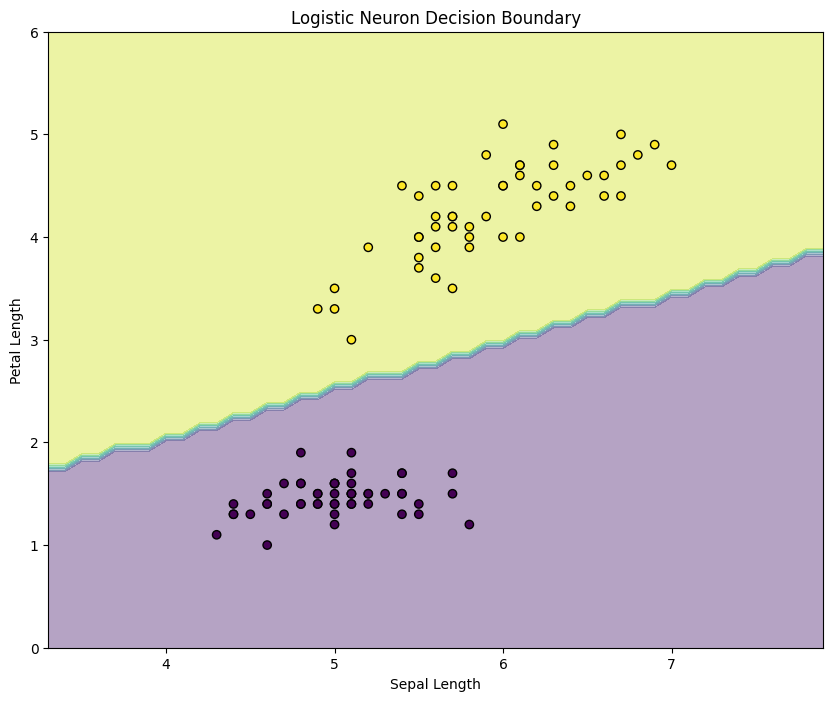

In [5]:
# Function to plot the decision boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel("Sepal Length")
    plt.ylabel("Petal Length")
    plt.title("Logistic Neuron Decision Boundary")
    plt.show()

plot_decision_boundary(X, y, logistic_neuron)

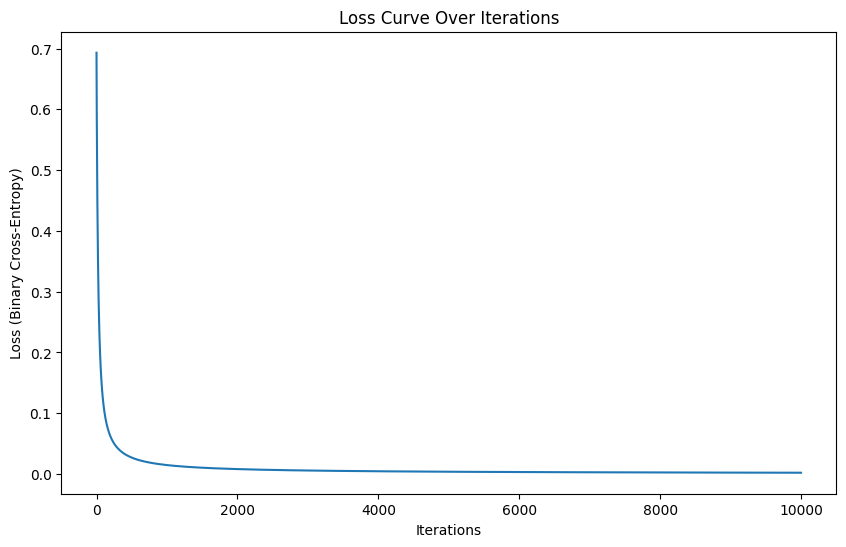

In [6]:
# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(logistic_neuron.iterations), logistic_neuron.loss_history)
plt.xlabel('Iterations')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.title('Loss Curve Over Iterations')
plt.show()

In [7]:
# Calculate accuracy
y_pred = logistic_neuron.predict(X)
accuracy = np.mean(y_pred == y)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00
